# Landsat NDVI Timeseries for the Central Peruvian Rainforest  

In the tropical rainforest of central Peru, deforestation is progressing rapidly. In need of more land for cultivation of in this case pineapple and cafe, farmes burn rainforest every year, "climbing" higher and higher into the mountains. First they settled near the river, now they are using fields in areas with high inclination. 
So the idea of this analysis was to demonstrate this development analyzing Landsat NDVI time series. Therefor I defined an AOI near the city of Pichanqui in Chanchamayo, Peru. 

To reproduce the code below you will need:
- a google earth engine account and the python API
- all the packages mentioned in the import section installed in your environment
- the notebook saved on your local machine, part 3 will create the folder "exports_no_forest" and download aprox. 100 KB of data and save it there. 

The notebook is divided in three parts:
1. NDVI timeseries analysis per decade, using L5, L7, L8 and L9 images
2. NDVI timeseries analysis per 5 year periode, only using L7
3. Timestep Map showing the deforestation per 5 year period

In [118]:
# First I import all the packages required for the analysis

import ee
import geemap
import os
import numpy as np
import rasterio
import pandas as pd
from rasterio.features import shapes
import geopandas as gpd
from shapely.geometry import shape
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


In [119]:
# Starting the Google Earth Engine

ee.Initialize()
print("EE initialized.")

EE initialized.


In [120]:
# I define my AOI - could be changed to whatever AOI you might like to investigate...

aoi = ee.Geometry.Polygon([[
    [-74.95454995735925,-10.965493099435431],
    [-74.81275765999597,-10.965493099435431],
    [-74.81275765999597,-10.864359559956089],
    [-74.95454995735925,-10.864359559956089],
    [-74.95454995735925,-10.965493099435431]
]])

aoi_area_km2 = aoi.area().divide(1e6)
print("AOI area (km²):", aoi_area_km2.getInfo())

AOI area (km²): 174.09661906236715


# Part 1: 
Trying to calculate the 10 year NDVI and then use the median for thresholding forest/no-forest

In [121]:
# Here I define my function, that selects the bands I need for the NDVI, for Landsat 5 and 7 those are bands 4 and 3,
# and for Landsat 8 and 9 bands 5 and 4. 


def ls_c2_l2_sr_ndvi(img):
    # Quality assessment bands for masking
    qa = img.select("QA_PIXEL")
    radsat = img.select("QA_RADSAT")

    # Mask out unwanted pixels (clouds, shadows, snow, fill, radiometric saturation)
    # Bits: 0 Fill, 1 Dilated cloud, 2 Cirrus, 3 Cloud, 4 Shadow, 5 Snow
    mask = (qa.bitwiseAnd(1 << 0).eq(0)
            .And(qa.bitwiseAnd(1 << 1).eq(0))
            .And(qa.bitwiseAnd(1 << 2).eq(0))
            .And(qa.bitwiseAnd(1 << 3).eq(0))
            .And(qa.bitwiseAnd(1 << 4).eq(0))
            .And(qa.bitwiseAnd(1 << 5).eq(0))
            .And(radsat.eq(0)))

    # Convert scaled integer SR values to physical reflectance (info is on GEE website for the sensors)
    optical = img.select("SR_B.*").multiply(0.0000275).add(-0.2)

    # Identify sensor family (Landsat 8/9 vs 5/7)
    sc = ee.String(img.get("SPACECRAFT_ID"))
    is_89 = ee.List(["LANDSAT_8", "LANDSAT_9"]).contains(sc)

    # Define red and NIR bands depending on sensor
    # L8/9: red = SR_B4, nir = SR_B5
    red_89 = optical.select("SR_B4")
    nir_89 = optical.select("SR_B5")

    # L5/7: red = SR_B3, nir = SR_B4
    red_57 = optical.select("SR_B3")
    nir_57 = optical.select("SR_B4")

    # Choose correct bands 
    red = ee.Image(ee.Algorithms.If(is_89, red_89, red_57))
    nir = ee.Image(ee.Algorithms.If(is_89, nir_89, nir_57))

    # Ensure physically valid reflectance values
    phys = red.gt(0).And(nir.gt(0))

    # NDVI formula
    ndvi = nir.subtract(red).divide(nir.add(red)).rename("NDVI")

    # Apply mask, clip to AOI, and keep metadata
    return (ndvi.updateMask(mask.And(phys))
                .clip(aoi)
                .copyProperties(img, img.propertyNames()))

In [122]:
# This function I will use later to select the images I need. It takes the collection_id, start- and end date and the maximum cloud cover as inputs
# and for every imagecollection it filters it for the aoibounds, the dates and the cloudcover. After filtering, it applies the NDVI function to every image 
# and then calculates the median NDVI composite for the whole period. 

def ndvi_decade(collection_id, start, end, cloud_cover_max):
    col = (ee.ImageCollection(collection_id)
           .filterBounds(aoi)
           .filterDate(start, end)
           .filter(ee.Filter.lte("CLOUD_COVER", cloud_cover_max))
           .map(ls_c2_l2_sr_ndvi))   # here I call the first function from above, for the cloudmasking
    ndvi_median = col.median().rename("NDVI").clip(aoi)
    return col, ndvi_median


In [123]:
# this function does almost the same as the above, but it merges the collections if there are several from different sensors for the same time period

def ndvi_decade_merge(collection_ids, start, end, cloud_cover_max):
    col = ee.ImageCollection(collection_ids[0])
    for cid in collection_ids[1:]:
        col = col.merge(ee.ImageCollection(cid))

    col = (col.filterBounds(aoi)
           .filterDate(start, end)
           .filter(ee.Filter.lte("CLOUD_COVER", cloud_cover_max))
           .map(ls_c2_l2_sr_ndvi)) # here I call the first function from above, for the cloudmasking

    ndvi_median = col.median().rename("NDVI").clip(aoi)
    return col, ndvi_median


Now I apply the functions from above for the time periods 1990-1999, 2000-2009, 2010-2019 and 2020-2025, using cloud cover maximum 50 %, because my AOI is in the tropical
rainforest region, where most of the images have high cloud cover. Since I apply cloud masking and am using an AOI rather in the valley than further up in the cloud forest
I decided that 50 % would be a good threshold to still have enough images. 


In [124]:
# 1990s (L5)
col_90s, ndvi_90s = ndvi_decade("LANDSAT/LT05/C02/T1_L2", "1990-01-01", "1999-12-31", 50)

# 2000s (L5 + L7)
col_00s, ndvi_00s = ndvi_decade_merge(
    ["LANDSAT/LT05/C02/T1_L2", "LANDSAT/LE07/C02/T1_L2"], 
    "2000-01-01", "2009-12-31", 50
    )

# 2010s (L7 + L8)
col_10s, ndvi_10s = ndvi_decade_merge(
    ["LANDSAT/LE07/C02/T1_L2", "LANDSAT/LC08/C02/T1_L2"],
    "2010-01-01", "2019-12-31", 50
)

# 2020s (L8 + L9) – 2025
col_20s, ndvi_20s = ndvi_decade_merge(
    ["LANDSAT/LC08/C02/T1_L2", "LANDSAT/LC09/C02/T1_L2"],
    "2020-01-01", "2025-12-31", 50
)

# To see how many images I used for calculating the NDVI I just quickly print the size of the imagecollection per time period. Seems to be enough for every time period.

print("1990s count:", col_90s.size().getInfo())
print("2000s count:", col_00s.size().getInfo())
print("2010s count:", col_10s.size().getInfo())
print("2020s count:", col_20s.size().getInfo())


1990s count: 130
2000s count: 237
2010s count: 230
2020s count: 143


In [125]:
# This function gives me some statistics, to inspect the data a little bit and get a feeling for the min, max and percentiles. 

def ndvi_stats(img, label):
    reducer = ee.Reducer.minMax().combine(
        ee.Reducer.percentile([50, 90]),
        sharedInputs=True
    )

    stats = img.reduceRegion(
        reducer=reducer,
        geometry=aoi,
        scale=250,        # if I don´t scale it up, I exceed my GEE memory...
        bestEffort=True,
        tileScale=16,
        maxPixels=1e13
    ).getInfo()

    print(label)
    if stats is None:
        print("  No data / fully masked")
    else:
        print(" ", stats)


Now I apply the function from above to all my data, just to get a feeling for it. I can already see, that there seems to be a difference between L5 and the others,
the p50 and p90 are lower for example. For the 2000s there are images from L5 and L7, which kind of smoothes the effect. 

In [126]:
ndvi_stats(ndvi_90s, "NDVI 1990s (median)")
ndvi_stats(ndvi_00s, "NDVI 2000s (median)")
ndvi_stats(ndvi_10s, "NDVI 2010s (median)")
ndvi_stats(ndvi_20s, "NDVI 2020s (median)")


NDVI 1990s (median)
  {'NDVI_max': 0.8185151947538034, 'NDVI_min': 0.1708622541772568, 'NDVI_p50': 0.7247267194641216, 'NDVI_p90': 0.775368993458871}
NDVI 2000s (median)
  {'NDVI_max': 0.8380631414666813, 'NDVI_min': 0.15749226480369571, 'NDVI_p50': 0.740226503387237, 'NDVI_p90': 0.7947315297866314}
NDVI 2010s (median)
  {'NDVI_max': 0.8608178617760789, 'NDVI_min': 0.11775876807016111, 'NDVI_p50': 0.7559484275642213, 'NDVI_p90': 0.814473360523971}
NDVI 2020s (median)
  {'NDVI_max': 0.8693698299848769, 'NDVI_min': 0.11555891592903976, 'NDVI_p50': 0.7480979268524931, 'NDVI_p90': 0.8144615772226306}


### Map of NDVI Median per decade 
What you can see in the map is the river and the center of the city of Pichanqui with very low NDVI values. You can also nicely see, how the river changed its course and the 
city really started to grow at the beginning of the 2000s. By looking at the surrounding forest area you can also already see, that the minimum values differ for the earlier
years and that there is some deforestation activity going on. 

In [127]:
# Now I display the NDVIs per decade on the GEE Map. I use the min and max values from above as a reference for my visualization scaling.

Map = geemap.Map()
Map.centerObject(aoi, 10)

ndvi_vis = {
    "min": 0.25,
    "max": 0.99
}

Map.addLayer(aoi, {}, "AOI")

Map.addLayer(ndvi_90s, ndvi_vis, "NDVI 1990s (median)")
Map.addLayer(ndvi_00s, ndvi_vis, "NDVI 2000s (median)")
Map.addLayer(ndvi_10s, ndvi_vis, "NDVI 2010s (median)")
Map.addLayer(ndvi_20s, ndvi_vis, "NDVI 2020s (median)")

Map 

Map(center=[-10.914931616152487, -74.88365380867597], controls=(WidgetControl(options=['position', 'transparen…

Differences between L5 and L7/8

To explore the data a little further, I compute the histogramms for the NDVI of every decade. I wanted to get a feeling for the distribution of the data to decide on a threshold. The blue line (L5 for the 1990s) has its peek at around 0.75, the green and the red line (L8 and L9 for the latest years) have their peek at around 0.8 and orange line (L5 and L7 for the 2000s ) is in the middle.

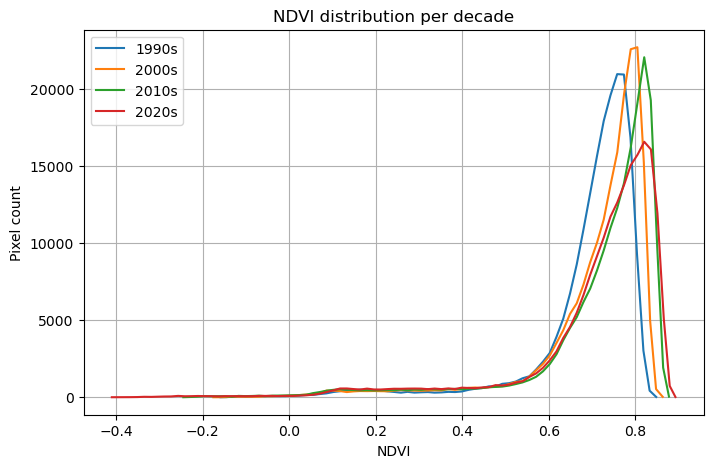

In [128]:
ndvi_images = {
    "1990s": ndvi_90s,
    "2000s": ndvi_00s,
    "2010s": ndvi_10s,
    "2020s": ndvi_20s
}

plt.figure(figsize=(8,5))

for label, img in ndvi_images.items():

    hist = img.reduceRegion(
        reducer=ee.Reducer.histogram(maxBuckets=100),
        geometry=aoi,
        scale=30,
        bestEffort=True,
        maxPixels=1e13
    ).getInfo()

    hist_data = hist["NDVI"]
    counts = hist_data["histogram"]
    bins = hist_data["bucketMeans"]

    plt.plot(bins, counts, label=label)

plt.xlabel("NDVI")
plt.ylabel("Pixel count")
plt.title("NDVI distribution per decade")
plt.legend()
plt.grid(True)

plt.show()

Now I apply a threshold of 0.7 for a simple classification of forest/no forest. I use 0.7, since there are plantations which also have a higher NDVI, but I want to classify
actual forest. 
As mentioned above, there seems to be a difference between the sensors, because in the 1990s, there seems to be less forest than in the 2020s. I definitly doubt this development. 


In [129]:
thr = 0.7

forest_vis = {
    "min": 0,
    "max": 1,
    "palette": ["FF0000", "006400"]  # no forest red/ forest green
}

forest_90s = ndvi_90s.gte(thr).rename("forest").clip(aoi)
forest_00s = ndvi_00s.gte(thr).rename("forest").clip(aoi)
forest_10s = ndvi_10s.gte(thr).rename("forest").clip(aoi)
forest_20s = ndvi_20s.gte(thr).rename("forest").clip(aoi)

import geemap
Map = geemap.Map()
Map.centerObject(aoi, 10)
Map.addLayer(aoi, {}, "AOI")

Map.addLayer(forest_90s, forest_vis, f"forest 1990s (NDVI ≥ {thr})")
Map.addLayer(forest_00s, forest_vis, f"forest 2000s (NDVI ≥ {thr})")
Map.addLayer(forest_10s, forest_vis, f"forest 2010s (NDVI ≥ {thr})")
Map.addLayer(forest_20s, forest_vis, f"forest 2020s (NDVI ≥ {thr})")

legend = {"no forest": "FF0000", "forest (NDVI ≥ 0.6)": "006400"}
Map.add_legend(title="Forestmask", legend_dict=legend)

Map


Map(center=[-10.914931616152487, -74.88365380867597], controls=(WidgetControl(options=['position', 'transparen…

To tackle the problem from above, that apparently the forest has been growing back in the last years, I tried to use these functions, that define the threshold based on the 
statistics for every decade. 

In [130]:
thr_z = -2 

def get_p50_p90_from_image(ndvi_img):
    # compute p50 and p90 over AOI from the NDVI image itself
    stats = ndvi_img.reduceRegion(
        reducer=ee.Reducer.percentile([50, 90]),
        geometry=aoi,
        scale=250,
        bestEffort=True,
        tileScale=16,
        maxPixels=1e13
    )
    p50 = ee.Number(stats.get("NDVI_p50"))
    p90 = ee.Number(stats.get("NDVI_p90"))
    return p50, p90

def forest_mask_from_p50_p90(ndvi_img, p50, p90, z_thr=-2.0):
    # z = (NDVI - p50) / (p90 - p50)
    denom = ee.Number(p90).subtract(p50)
    z = ndvi_img.subtract(ee.Number(p50)).divide(denom)
    return z.gte(z_thr).rename("forest")

In [131]:
# Put decade NDVI images in a dictionary for looping
ndvi_decades = {
    "1990s": ndvi_90s,
    "2000s": ndvi_00s,
    "2010s": ndvi_10s,
    "2020s": ndvi_20s,
}

# Build forest masks dynamically based on the function from above
forest_decades = {}

for label, ndvi_img in ndvi_decades.items():
    p50, p90 = get_p50_p90_from_image(ndvi_img)
    forest = forest_mask_from_p50_p90(ndvi_img, p50, p90, z_thr=thr_z).clip(aoi)
    forest_decades[label] = forest

In [132]:
# Here I just wanted to see the results of my functions above, in order to understand what was happening. The thresholds don´t differ too much. 

def effective_ndvi_threshold(p50, p90, z_thr):
    return ee.Number(p50).add(ee.Number(z_thr).multiply(ee.Number(p90).subtract(p50)))

for label, ndvi_img in ndvi_decades.items():
    p50, p90 = get_p50_p90_from_image(ndvi_img)
    thr_ndvi = effective_ndvi_threshold(p50, p90, thr_z)
    print(label, "effective NDVI threshold ≈", thr_ndvi.getInfo())

1990s effective NDVI threshold ≈ 0.6234421714746228
2000s effective NDVI threshold ≈ 0.631216450588448
2010s effective NDVI threshold ≈ 0.6388985616447219
2020s effective NDVI threshold ≈ 0.6153706261122182


Now I visualize the new, scaled layers. I can already see, that the scaled thresholds don´t differ a lot and that the threshold for the 1990s is similar to the one for the 2020s, which does´t seem to solve the problem. I tried different approaches, but unfortunately I couldn´t get a convincing result. The main problem seems to be that the function above uses the p50 and p90 values, which don´t differ a lot. I see the problem more in the differences for the min and max values. 

There probably is a way of "harmonizing" the different sensors, I did some research and also tried different things, but nothing convinced me... So below the visualization of the harmonized thresholds I continue with part 2, where I decided to only continue using the L7 sensor, therfore starting in 2000 and using 5 years time steps.

In [133]:
# So I visualize the new, scaled layers, the effective threshold applied is shown in the legend

forest_vis = {"min": 0, "max": 1, "palette": ["FF0000", "006400"]}
Map = geemap.Map()
Map.centerObject(aoi, 10)
Map.addLayer(aoi, {}, "AOI")

thresholds = {}

for label, ndvi_img in ndvi_decades.items():
    
    p50, p90 = get_p50_p90_from_image(ndvi_img)
    thr_ndvi = effective_ndvi_threshold(p50, p90, thr_z)
    
    thr_val = thr_ndvi.getInfo()
    thresholds[label] = round(thr_val, 3)
    
    forest = forest_mask_from_p50_p90(ndvi_img, p50, p90, z_thr=thr_z).clip(aoi)
    
    Map.addLayer(
        forest,
        forest_vis,
        f"forest {label} (NDVI ≥ {round(thr_val,3)})"
    )

legend_dict = {
    "No-forest": "FF0000",
    "Forest": "006400"
}

for label, thr in thresholds.items():
    legend_dict[f"{label} threshold: {thr}"] = "FFFFFF"

Map.add_legend(
    title="Forest mask (dynamic NDVI threshold)",
    legend_dict=legend_dict
)

Map


Map(center=[-10.914931616152487, -74.88365380867597], controls=(WidgetControl(options=['position', 'transparen…

# Part 2:
Landsat 7 NDVI 5 year timeseries 2000-2024

In [134]:
# So now I use the function from above again, to get my images and count how many there are per 5 year time period. Also seems to be a sufficient number, 
# maximum cloud cover is 50 % again. 

periods_5yr = [
    ("2000-01-01", "2004-12-31", "2000–2004"),
    ("2005-01-01", "2009-12-31", "2005–2009"),
    ("2010-01-01", "2014-12-31", "2010–2014"),
    ("2015-01-01", "2019-12-31", "2015–2019"),
    ("2020-01-01", "2024-12-31", "2020–2024"),
]

ndvi_5yr = {}
cols_5yr = {}

for start, end, label in periods_5yr:
    col, ndvi = ndvi_decade(
        "LANDSAT/LE07/C02/T1_L2",  # Landsat 7 only
        start, end, 50              # max cloud cover 50 %
    )
    cols_5yr[label] = col
    ndvi_5yr[label] = ndvi
    print(label, "image count:", col.size().getInfo())



2000–2004 image count: 57
2005–2009 image count: 64
2010–2014 image count: 72
2015–2019 image count: 72
2020–2024 image count: 77


And again I apply the stats function from above, to get an idea. Doesn´t look perfect, but let´s see the visualization below. 
Something seems to have happend in the years 2020-2024

In [135]:
for _, _, label in periods_5yr:
    ndvi_stats(ndvi_5yr[label], f"NDVI {label} (median):")


NDVI 2000–2004 (median):
  {'NDVI_max': 0.860744122739211, 'NDVI_min': 0.12113407784019004, 'NDVI_p50': 0.7793417444795078, 'NDVI_p90': 0.8261909251126401}
NDVI 2005–2009 (median):
  {'NDVI_max': 0.8575962505924233, 'NDVI_min': 0.11355852203274967, 'NDVI_p50': 0.7517320835892192, 'NDVI_p90': 0.8183566194931842}
NDVI 2010–2014 (median):
  {'NDVI_max': 0.8612889218830979, 'NDVI_min': 0.10155595231430053, 'NDVI_p50': 0.7361159166353048, 'NDVI_p90': 0.8107681028256005}
NDVI 2015–2019 (median):
  {'NDVI_max': 0.8594513505050284, 'NDVI_min': 0.1062938399930084, 'NDVI_p50': 0.7401766271150031, 'NDVI_p90': 0.8065466874388207}
NDVI 2020–2024 (median):
  {'NDVI_max': 0.8002677973666592, 'NDVI_min': 0.11837048424289007, 'NDVI_p50': 0.5760307768355797, 'NDVI_p90': 0.6896043158813843}


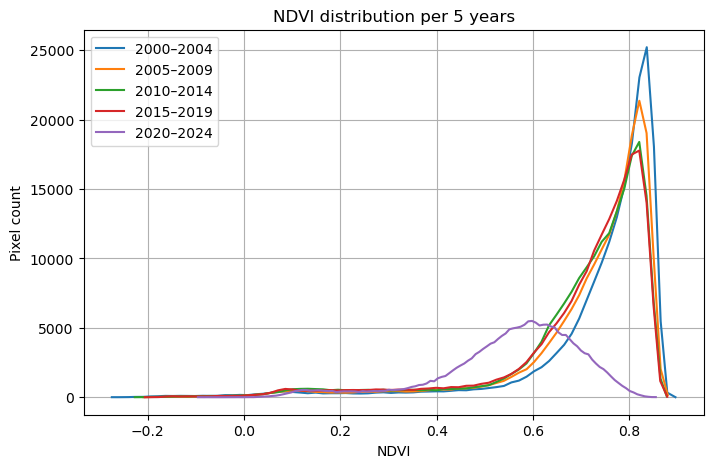

In [136]:
# I plot the histograms again, to get a better feeling for the data. 

plt.figure(figsize=(8,5))

for label, img in ndvi_5yr.items():

    hist = img.reduceRegion(
        reducer=ee.Reducer.histogram(maxBuckets=100),
        geometry=aoi,
        scale=30,
        bestEffort=True,
        maxPixels=1e13
    ).getInfo()

    hist_data = hist["NDVI"]
    counts = hist_data["histogram"]
    bins = hist_data["bucketMeans"]

    plt.plot(bins, counts, label=label)

plt.xlabel("NDVI")
plt.ylabel("Pixel count")
plt.title("NDVI distribution per 5 years")
plt.legend()
plt.grid(True)

plt.show()

What you can see in the histogram is interesting, something seems to have happend to the sensor in the last years of its mission. There is clearly something going on, so since the image count is similar for all time periods, I plot the distribution per month below, just in case. It is a tropical area but the summers are also becoming hotter and drier, but as you can see below, that doesn´t seem to be the reason. Some research didn´t give me a clear answer either, the problem with the scan line corrector has been ongoing since 2003, there hasn´t been reports of such a strong degradation and calibration parameters do change, but that much?

So again, for the sake of having meaningful results I decide to exclude the time period 2020-2024. 

Additionaly you can see that most of the images I use correspond to the drier season, since the months from october to march are the ones with usually heavy rainfall in the area, and therefor I expect high cloud coverage. 

<Figure size 1200x600 with 0 Axes>

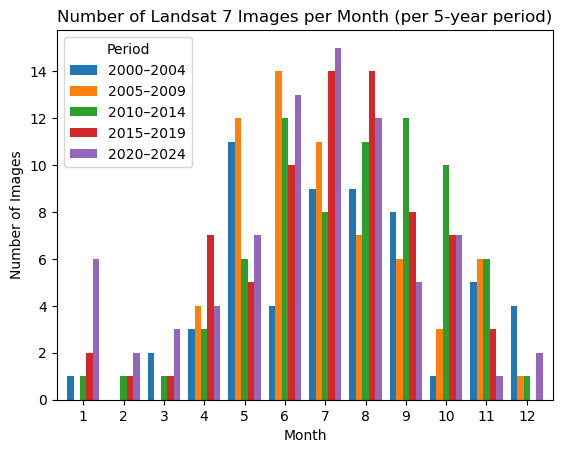

    2000–2004  2005–2009  2010–2014  2015–2019  2020–2024
1           1          0          1          2          6
2           0          0          1          1          2
3           2          0          1          1          3
4           3          4          3          7          4
5          11         12          6          5          7
6           4         14         12         10         13
7           9         11          8         14         15
8           9          7         11         14         12
9           8          6         12          8          5
10          1          3         10          7          7
11          5          6          6          3          1
12          4          1          1          0          2


In [137]:
# Since I already did some processing with the data above I did loose the metadata on the month, so I just started over defining the 5 year periods and getting the available 
# L7 images 

periods_5yr = [
    ("2000-01-01", "2004-12-31", "2000–2004"),
    ("2005-01-01", "2009-12-31", "2005–2009"),
    ("2010-01-01", "2014-12-31", "2010–2014"),
    ("2015-01-01", "2019-12-31", "2015–2019"),
    ("2020-01-01", "2024-12-31", "2020–2024"),
]

all_month_counts = pd.DataFrame(index=range(1,13))  

for start, end, label in periods_5yr:
    col = (ee.ImageCollection("LANDSAT/LE07/C02/T1_L2")
           .filterBounds(aoi)
           .filterDate(start, end)
           .filter(ee.Filter.lte("CLOUD_COVER", 50)))
    
    timestamps = col.aggregate_array('system:time_start').getInfo()
    months = [pd.to_datetime(ts, unit='ms').month for ts in timestamps]
    month_counts = pd.Series(months).value_counts().sort_index()
    month_counts = month_counts.reindex(range(1,13), fill_value=0)
    
    all_month_counts[label] = month_counts

# Plot
plt.figure(figsize=(12,6))
all_month_counts.plot(kind='bar', rot=0, width=0.8)
plt.xlabel('Month')
plt.ylabel('Number of Images')
plt.title('Number of Landsat 7 Images per Month (per 5-year period)')
plt.legend(title='Period')
plt.show()

print(all_month_counts)

In [138]:
# Now I visualize my results again, but first I exclude the time period 2020-2024

forest_thr = 0.7  # I use 0.7 because there are plantations in the area that I assume have NDVI values around 0.5-0.7

# Create forest masks (1 = forest, 0 = non-forest)
forest_5yr = {
    label: ndvi_5yr[label].gte(forest_thr).rename("forest").clip(aoi)
    for label in ndvi_5yr.keys() if label != "2020–2024"    # I exclude the last time period
}

# Visualization: red = non-forest, green = forest
forest_vis = {"min": 0, "max": 1, "palette": ["FF0000", "006400"]}

Map = geemap.Map()
Map.centerObject(aoi, 10)

Map.addLayer(aoi, {}, "AOI")

# Add each time period as a separate layer
for label in sorted(forest_5yr.keys()):
    Map.addLayer(forest_5yr[label], forest_vis, f"Forest mask {label} (NDVI ≥ {forest_thr})")

Map.add_legend(
    title=f"Forest mask (NDVI ≥ {forest_thr})",
    legend_dict={"Non-forest": "FF0000", "Forest": "006400"}
)

Map



Map(center=[-10.914931616152487, -74.88365380867597], controls=(WidgetControl(options=['position', 'transparen…

Now I added the class "water" since it has a very low NDVI. In summertime the rivers in that area have low water, so therefor the riverbed and the little rivers don´t appear blue. The city center seems to also have areas with very low NDVI. Since the no-forest areas are mostly used for plantations, the still have higher NDVI values and get there own class. But now you can definitely see a trend that corresponds with what is happening in most tropical rainforest areas: The cities grow and forest is cut down for fields, every year further up the mountains. 

In [139]:
# Thresholds
water_thr = 0.1
city_thr = 0.5         
plantation_thr = 0.7   
   
class_5yr = {}

for label, ndvi_img in ndvi_5yr.items():
    if label == "2020–2024":
        continue  # skip the last period

    # Classes
    water = ndvi_img.lte(water_thr)
    city = ndvi_img.gt(water_thr).And(ndvi_img.lte(city_thr))
    plantation = ndvi_img.gt(city_thr).And(ndvi_img.lt(plantation_thr))
    forest = ndvi_img.gte(plantation_thr)

    # Combine into a single classification image
    cls = (water.multiply(0)
           .add(city.multiply(1))
           .add(plantation.multiply(2))
           .add(forest.multiply(3))
           .rename("class")
           .clip(aoi))

    class_5yr[label] = cls

# Visualization: water = blue, city = gray, plantation = orange, forest = green
class_vis = {
    "min": 0,
    "max": 3,
    "palette": [
        "0000FF",  # 0 water
        "AAAAAA",  # 1 city/riverbed
        "FFA500",  # 2 plantation
        "006400"   # 3 forest
    ]
}

# Plot
import geemap
Map = geemap.Map()
Map.centerObject(aoi, 10)
Map.addLayer(aoi, {}, "AOI")

for label in sorted(class_5yr.keys()):
    Map.addLayer(class_5yr[label], class_vis, f"Classes {label}")

Map.add_legend(
    title="NDVI classes",
    legend_dict={
        "Water": "0000FF",
        "City and Rivebeds": "AAAAAA",
        "Plantation": "FFA500",
        "Forest": "006400"
    }
)

Map

Map(center=[-10.914931616156137, -74.88365380867833], controls=(WidgetControl(options=['position', 'transparen…

# Part 3: 
Creating a timestep map with the forest/no-forest data. In order for the code to work from this point, you need to have the file saved on your computer, so that os knows where to save the data. 

In [140]:
# this part exports the no-forest mask to your machine, if they already exist it skips this part.

forest_thr = 0.7  
out_dir = "exports_no_forest"
os.makedirs(out_dir, exist_ok=True)

# Build no-forest masks (1 = no-forest, 0 = else), exclude 2020–2024
no_forest_5yr = {
    label: ndvi_5yr[label].lt(forest_thr).rename("no_forest").clip(aoi)
    for label in ndvi_5yr.keys() if label != "2020–2024"
}

tif_files = {}

for label, img in no_forest_5yr.items():
    fn = os.path.join(
        out_dir,
        f"no_forest_{label.replace('–','-').replace(' ','')}.tif"
    )

    tif_files[label] = fn  

    # ---- CHECK IF FILE ALREADY EXISTS ----
    if os.path.exists(fn):
        print(f"exists, skipping download: {fn}")
        continue

    # ---- EXPORT ONLY IF NOT EXISTS ----
    geemap.ee_export_image(
        img,
        filename=fn,
        scale=30,
        region=aoi,
        file_per_band=False,
        crs="EPSG:32718"   # UTM 18S
    )

    print(f"exported: {fn}")


exists, skipping download: exports_no_forest\no_forest_2000-2004.tif
exists, skipping download: exports_no_forest\no_forest_2005-2009.tif
exists, skipping download: exports_no_forest\no_forest_2010-2014.tif
exists, skipping download: exports_no_forest\no_forest_2015-2019.tif


In [141]:
# Here I create Vector data from my raster data above, one polygon per 5 year time period

gdfs = {}

for label, tif in tif_files.items():
    with rasterio.open(tif) as src:
        arr = src.read(1)
        transform = src.transform
        crs = src.crs
        nodata = src.nodata

        # Make sure we ignore nodata if it exists
        if nodata is not None:
            valid = (arr != nodata)
        else:
            valid = np.isfinite(arr)

        mask = valid & (arr > 0.5)

        geoms = []
        for geom, val in shapes(arr.astype(np.uint8), mask=mask, transform=transform):
            if int(val) == 1:
                geoms.append(shape(geom))

    gdf = gpd.GeoDataFrame({"period": [label] * len(geoms)}, geometry=geoms, crs=crs)

    if len(gdf) > 0:
        # Dissolve to one (or few) polygons per period
        gdf = gdf.dissolve(by="period").reset_index()

        # Simplify geometry (UTM meters)
        gdf["geometry"] = gdf["geometry"].simplify(tolerance=30, preserve_topology=True)

    gdfs[label] = gdf
    print(label, "polygons:", len(gdf))


2000–2004 polygons: 1
2005–2009 polygons: 1
2010–2014 polygons: 1
2015–2019 polygons: 1


In [142]:
# just some helper functions for displaying a north arrow and a scale bar

def add_north_arrow(ax, x=0.06, y=0.92, size=0.08, color="black"):
    
    ax.annotate(
        "N",
        xy=(x, y),
        xytext=(x, y - size),
        xycoords=ax.transAxes,
        textcoords=ax.transAxes,
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold",
        arrowprops=dict(arrowstyle="-|>", lw=1.8, color=color),
        color=color,
    )

def add_scale_bar(ax, length_km=10, location=(0.55, 0.06), linewidth=4, color="black"):
    
    # Convert km to meters
    length_m = length_km * 1000

    # Get current axis limits in data coordinates (meters)
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()

    # Place the scalebar using axes-fraction coordinates converted to data coords
    x_start = x0 + (x1 - x0) * location[0]
    y_start = y0 + (y1 - y0) * location[1]

    # Draw the bar
    ax.add_line(Line2D([x_start, x_start + length_m], [y_start, y_start],
                       lw=linewidth, color=color, solid_capstyle="butt"))

    # End ticks
    tick_h = (y1 - y0) * 0.01
    ax.add_line(Line2D([x_start, x_start], [y_start - tick_h, y_start + tick_h],
                       lw=1.2, color=color))
    ax.add_line(Line2D([x_start + length_m, x_start + length_m], [y_start - tick_h, y_start + tick_h],
                       lw=1.2, color=color))

    # Labels
    ax.text(x_start, y_start + 2.2 * tick_h, "0", ha="center", va="bottom", fontsize=10, color=color)
    ax.text(x_start + length_m, y_start + 2.2 * tick_h, f"{length_km} km", ha="center", va="bottom", fontsize=10, color=color)


### The actual final plotting part, using matplotlib:

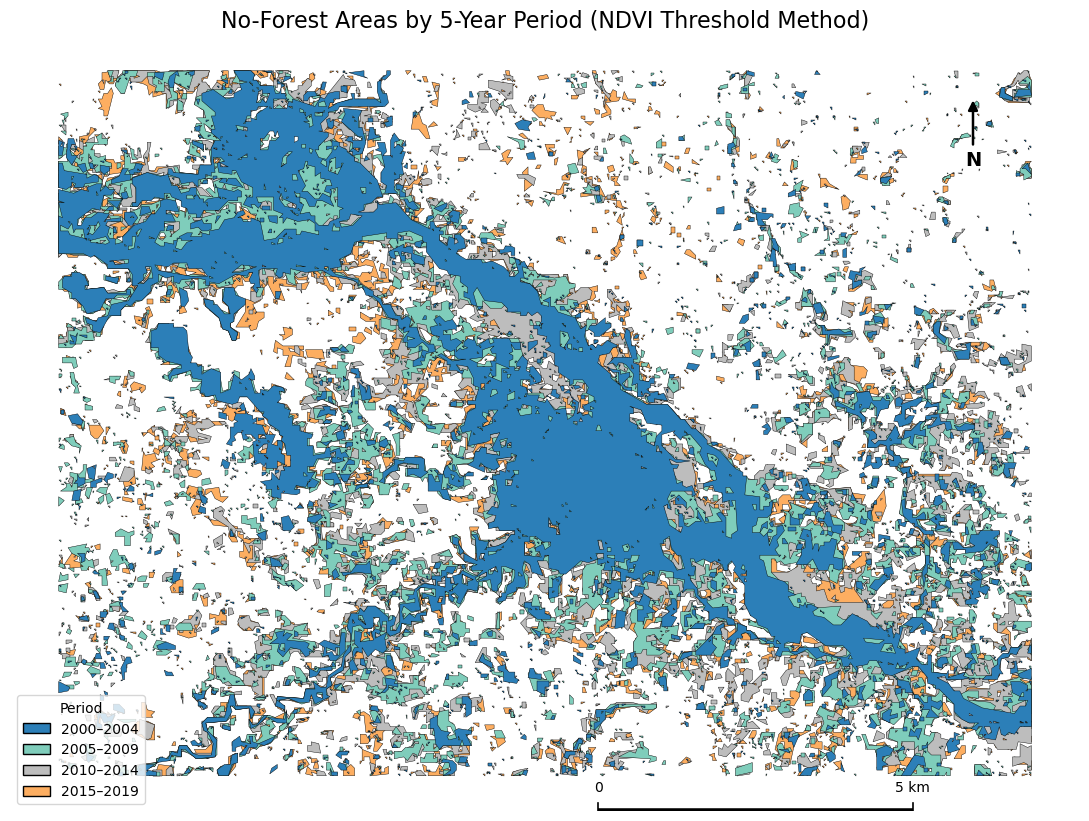

In [143]:
# Color ramp: oldest -> newest (blue to red)
# (choose 5 colors for your 5 periods)
colors_scale = [
    "#2C7FB8",  # oldest: blue
    "#7FCDBB",  # blue-green (still cool)
    "#BDBDBD",  # neutral grey
    "#FDAE61",  # orange
    "#D73027",  # newest: red
]

fig, ax = plt.subplots(figsize=(11, 9))

legend_patches = []

# Plot newest first so the earliest boundary remains visible on top
rev_periods = list(reversed(periods_5yr))

for i, (_, _, label) in enumerate(rev_periods):
    gdf = gdfs.get(label)
    if gdf is None or len(gdf) == 0:
        continue

    # correct color index back to chronological scale
    color = colors_scale[len(periods_5yr) - 1 - i]

    gdf.plot(
        ax=ax,
        facecolor=color,
        edgecolor="black",   # thin border helps without transparency
        linewidth=0.3
    )

    legend_patches.append(Patch(facecolor=color, edgecolor="black", label=label))

ax.set_title("No-Forest Areas by 5-Year Period (NDVI Threshold Method)", fontsize=16)
ax.set_axis_off()

# Legend chronological (old → new)
legend_patches = legend_patches[::-1]
ax.legend(handles=legend_patches, title="Period", loc="lower left", frameon=True)

# Add north arrow + scale bar
add_north_arrow(ax, x=0.9, y=0.92, size=0.08)
add_scale_bar(ax, length_km=5, location=(0.55, 0.0))

plt.tight_layout()
plt.show()


# Discussion and conclusion
On the map you can see the city center, the rivers and the expanding deforestation. The blue areas have been no-forest areas since the beginning of the century and then there are new parcels of no-forest area for every 5-year period. The fields are pretty small and of different shapes and most of the times areas close to each other correspond to consecutive time-periods. That could be interpreted in a way, that the farmers first work on one parcel, and then extend it step by step or more people start to use the land in the area. The terrain further away from the river rapidly starts to become steeper and therefor more difficult to work on, but the need of more land for plantations drives the people into those terrains. So the observed pattern coincides with the expected development, even though there are some debilities concerning the method.

The use of optical data always comes with the problem of cloud cover, especially in tropical regions. I tried more remote areas, "up the mountain" but there are not very many cloudfree pixels. Therefor I chose an AOI in the lower region, with less cloud cover. 

The thresholds applied can also be discussed, the small-scale changes of coffee plantations (sometimes even with trees for shadow), regrowth-areas and remaining forest are quite challenging. For a further analysis, ground truth data should be considered, since it is also difficult to distinguish those classes in the optical landsat images, because of the coarse resolution. 
 
Also, the described problem with the different sensors, that partly could not even be explained by myself, result in a shorter timeseries. So in order to use this approach in different areas and on greater scales, it would definitely need some refinement. Especially for longer time series, because you would want to use different Landsat Sensors, not only L7 like I did. The harmonized Sentinel and Landsat data set could be an option, as well as the use SAR-data instead of optical, VH-polarized data could also be used to detect deforestation for example. 
